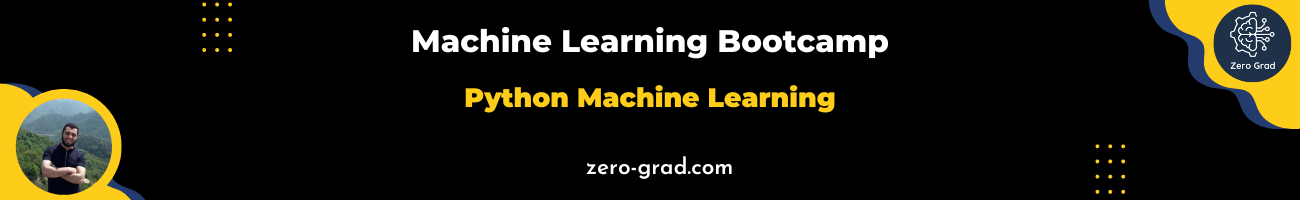

# Importing  libraries

In [1]:
import numpy as np
from sklearn.datasets import make_moons, make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.ensemble import VotingClassifier, BaggingClassifier, AdaBoostClassifier, VotingRegressor, \
                            GradientBoostingClassifier, RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR

# filter warnings
import warnings
warnings.filterwarnings('ignore')

#Visulaization
import plotly.express as px
import plotly.io as pio
pio.templates.default = 'presentation'

# Random Classification Data Generation

In [2]:
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [3]:
px.scatter(x=X[:,0], y=X[:,1], color= y, width=600)

# Weak Classification Learners

In [4]:
# Logistic Regression
lr = LogisticRegression()

# KNN
tree = DecisionTreeClassifier(random_state=42)

# SVM
svm = SVC(probability=True)

for clf in [lr, tree, svm]:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, ':', accuracy_score(y_test, y_pred))

LogisticRegression : 0.864
DecisionTreeClassifier : 0.856
SVC : 0.896


# Voting Classifier

In [5]:
# Hard Voting Classifier
voting_clf = VotingClassifier(estimators=[('lr', lr), ('tree', tree), ('svm', svm)], voting='hard')

# Train the model
voting_clf.fit(X_train, y_train)

# Predictions
y_pred = voting_clf.predict(X_test)

# Accuracy
print('Test Accuracy: ', accuracy_score(y_test, y_pred))

Test Accuracy:  0.904


In [6]:
# Soft Voting Classifier
voting_clf = VotingClassifier(estimators=[('lr', lr), ('tree', tree), ('svm', svm)], voting='soft')

# Train the model
voting_clf.fit(X_train, y_train)

# Predictions
y_pred = voting_clf.predict(X_test)

# Accuracy
print('Test Accuracy: ', accuracy_score(y_test, y_pred))

Test Accuracy:  0.912


# Bagging Classifier

In [7]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, max_samples=100, bootstrap=True, n_jobs=-1, random_state=42)

bag_clf.fit(X_train, y_train)

y_pred = bag_clf.predict(X_test)

print('Test Accuracy: ', accuracy_score(y_test, y_pred))

Test Accuracy:  0.904


# Random Forest Classifier

In [8]:
forest = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1, random_state=42)

forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)

print('Test Accuracy: ', accuracy_score(y_test, y_pred))

Test Accuracy:  0.912


# AdaBoost Classifier

In [9]:
adaboost = AdaBoostClassifier(DecisionTreeClassifier(max_depth=2), n_estimators=500, learning_rate=0.01, random_state=42)

adaboost.fit(X_train, y_train)

y_pred = adaboost.predict(X_test)

print('Test Accuracy: ', accuracy_score(y_test, y_pred))

Test Accuracy:  0.872


# Random Regression Data Generation

In [10]:
X, y = make_regression(n_samples=500, n_features=20,  noise=0.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Weak Regression Learners


In [11]:
lr = LinearRegression()
dt = DecisionTreeRegressor(max_depth=3)
svr = SVR(kernel='linear')

for reg in [lr, dt, svr]:
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)
    print(reg.__class__.__name__, ':', np.sqrt(mean_squared_error(y_test, y_pred)))

LinearRegression : 0.5056034830935469
DecisionTreeRegressor : 96.21706088765313
SVR : 0.620090851856968


# Voting Regressor

In [12]:
voting_reg = VotingRegressor(estimators=[('lr', lr), ('dt', dt), ('svr', svr)])

voting_reg.fit(X_train, y_train)

y_pred = voting_reg.predict(X_test)

print('Test RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred)))

Test RMSE:  32.132026879731214


# Random Forest Regressor

In [13]:
reg_forest = RandomForestRegressor(n_estimators=500, max_leaf_nodes=20, n_jobs=-1, random_state=42)

reg_forest.fit(X_train, y_train)

y_pred = reg_forest.predict(X_test)

print('Test RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred)))

Test RMSE:  72.81905853375272


# Gradient Boosting Regressor

In [14]:
gbr = GradientBoostingRegressor(max_depth=2, n_estimators=200, learning_rate=1.0, random_state=42)

gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)

print('Test RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred)))

Test RMSE:  64.06147971446501


# XGBoost Regressor

In [15]:
from xgboost import XGBRegressor

xgb = XGBRegressor(max_depth=3, n_estimators=300, learning_rate=0.1, random_state=42)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print('Test RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred)))

Test RMSE:  42.065138823757465
